# Evaluate the effects of intrinsic dispersion due to attenuation on Rayleigh waves
Compare the dispersion and waveforms between purely elastic and anelastic Earth. The codes were developed with assistance from Gemini, verified by Xiaotao Yang for accuracy. See Methods section in the manuscript for a detailed description of the method and parameters.

Following the reviewer's critique in the second round of evaluation, the updated code correctly implements **modulus relaxation**—ensuring that the anelastic velocity ($V_{anelastic}$) is slower than the purely elastic, unrelaxed velocity ($V_{\infty}$).

**The Formula:** We use the power-law dispersion relationship derived from **Minster (1978)** and **Liu et al. (1976)**:


$$V(\omega) = V_{\infty} \left[ 1 - \frac{1}{2} \cot\left(\frac{\pi \alpha}{2}\right) Q(\omega)^{-1} \right]$$

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Derived alpha: 0.3000
Period (s) | Reduction (%) for Q=200 at 100s | Reduction (%) for Q=111 at 100s | Reduction (%) for Q=60 at 100s
      15.0 |                          -0.28 |                          -0.50 |                          -0.93
      50.0 |                          -0.40 |                          -0.72 |                          -1.33
     100.0 |                          -0.49 |                          -0.88 |                          -1.64


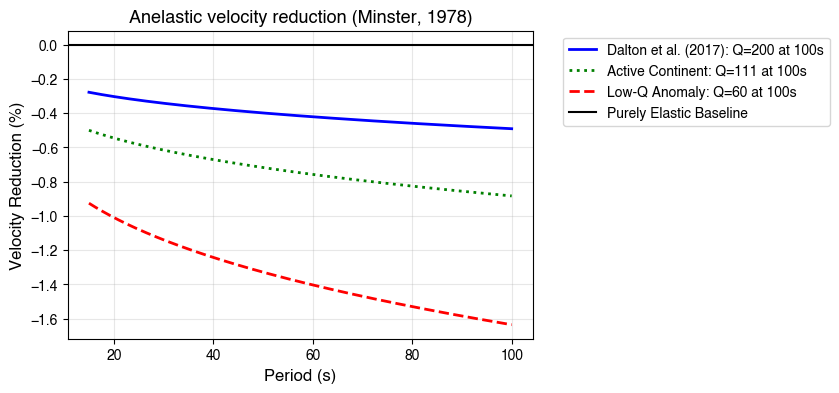

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rc('font',family='Helvetica')

# 1. Setup based on Reviewer #5 / Dalton et al. (2017)
periods = np.linspace(15, 100, 200) 
freqs = 1.0 / periods

# use 0.3 for alpha. add reference for this value.
# Jackson 2010
alpha = 0.3
f_ref = 0.01 # Reference at 100s
cot_term = 1.0 / np.tan(np.pi * alpha / 2.0)

# reference paper for the physical dispersion: 
# J. B. Minster, Transient and impulse responses of a one-dimensional linearly attenuating medium — II. 
# A parametric study, Geophysical Journal International, Volume 52, Issue 3, March 1978, Pages 503–524,
#  https://doi.org/10.1111/j.1365-246X.1978.tb04246.x
# phase velocity reduction (%) relative to unrelaxed state (v_inf) due to anelasticity is given by:
# v(f) = v_inf * [1 - 0.5 * cot(pi*alpha/2) * Q(f)^-1]
def calc_reduction(Q_at_100s):
    Q_f = Q_at_100s * (freqs / f_ref)**alpha
    reduction = -0.5 * cot_term * (1.0 / Q_f) * 100
    return reduction

# Calculate for Dalton baseline and a Low-Q Anomaly at 100 seconds
craton_Q = 1/0.005 # Q=200 at at 100s. Dolton et al. (2017) used Q=200 at 100s for cratonic regions, which corresponds to a very low attenuation (high Q) and thus minimal velocity reduction.
# chosen for value in Figure 6, between values for region P and region S.
active_Q = 1/0.009 # at 100 s. chosen for region Q: active continent. 
low_Q = 60 # Q=60 at 100s, chosen for the localized low-Q anomaly, which corresponds to a much higher attenuation (lower Q) and thus a more significant velocity reduction.
perc_dalton = calc_reduction(craton_Q) # Craton baseline
perc_active = calc_reduction(active_Q)  # Active continent baseline
perc_channel = calc_reduction(low_Q)  # Localized Low-Q feature

# 2. Plotting the correct physical relaxation
plt.figure(figsize=(6, 4))
plt.plot(periods, perc_dalton, 'b-', linewidth=2, label=f'Dalton et al. (2017): Q=%d at 100s'%(craton_Q))
plt.plot(periods, perc_active, 'g:', linewidth=2, label=f'Active Continent: Q=%d at 100s'%(active_Q))
plt.plot(periods, perc_channel, 'r--', linewidth=2, label=f'Low-Q Anomaly: Q=%d at 100s'%(low_Q))
plt.axhline(0, color='black', linewidth=1.5, label='Purely Elastic Baseline')

plt.ylabel('Velocity Reduction (%)', fontsize=12)
plt.xlabel('Period (s)', fontsize=12)
plt.title('Anelastic velocity reduction (Minster, 1978)', fontsize=13)
# plot legend outside the plot area to avoid overlapping with the curves.
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('corrected_anelastic_reduction.pdf', dpi=300)
# suggested caption for the figure in manuscript:
# "Figure X: Anelastic velocity reduction as a function of period based on the physical dispersion relation from Minster (1978). 
# The blue curve represents the baseline case with Q=100 at 100s, while the red dashed curve shows the effect of a localized low-Q anomaly with Q=60 at 100s. 
# The horizontal black line indicates the purely elastic baseline with no anelastic attenuation. This figure illustrates how anelasticity leads to 
# frequency-dependent velocity reductions, with more significant effects at longer periods."

#print a table of the values at 15s, 50s, and 100s for both cases with craton Q and low Q.
print("Period (s) | Reduction (%%) for Q=%d at 100s | Reduction (%%) for Q=%d at 100s | Reduction (%%) for Q=%d at 100s" % (craton_Q, active_Q, low_Q))
for p in [15, 50, 100]:
    idx = np.argmin(np.abs(periods - p))
    print(f"{periods[idx]:>10.1f} | {perc_dalton[idx]:>30.2f} | {perc_active[idx]:>30.2f} | {perc_channel[idx]:>30.2f}")